In [ ]:
# load the drive helper and mount
from google.colab import drive

# this will prompt for authorization. Please Accept the auth request
drive.mount('/content/drive')

## now you should be able to see the drive folder accessible by collab

Mounted at /content/drive


### How We Built the Models: A Detailed Overview

When asked about the model building process, you can explain it in several key stages:

#### 1. Data Preparation

*   **Loading Data**: The initial data consisted of face embeddings (features) and corresponding labels ('fake' or 'real'). This was loaded from a CSV file (`cleaned_data_resnet18_face_embeddings.csv`).
*   **Scaling**: A custom `lalos_scaling_function` was used to prepare the data. This involved:
    *   Dropping irrelevant columns (`Unnamed: 0`, `image_path`).
    *   Ensuring all feature columns were numeric and handling any `NaN` values by filling them with the column's median.
    *   Normalizing labels to 0 and 1 if they were 'fake'/'real' strings.
    *   Applying `StandardScaler` to the feature set (`X`) to normalize the data, which is crucial for many machine learning algorithms, especially distance-based ones like SVMs and neural networks.
*   **Dimensionality Reduction (SVD)**: To explore the impact of feature dimensionality, `TruncatedSVD` was applied to the scaled data to reduce the number of features to 200, 100, and 20 dimensions. This helps in speeding up training and potentially mitigating the curse of dimensionality.
*   **Train-Test Split**: For all models, the data was split into training and testing sets using `train_test_split` with a 80/20 ratio and `random_state=42` for reproducibility. This ensures that models are evaluated on unseen data.

#### 2. Model Architectures

We explored two main deep learning architectures: Convolutional Neural Networks (CNNs) and Multi-Layer Perceptrons (MLPs).

##### Convolutional Neural Network (CNN)

*   **Purpose**: Primarily designed for processing grid-like data (like images) but adapted here for 1D feature vectors. The `Conv1D` layers can capture local patterns within the sequential feature vector.
*   **Input**: The scaled embedding data was reshaped from `(samples, features)` to `(samples, features, 1)` to fit the `Conv1D` layer's expected input format (batch, steps, input_dim).
*   **Layers**:
    *   **Input Layer**: `Conv1D(filters=32, kernel_size=3, activation='relu')` followed by `BatchNormalization`, `MaxPooling1D(pool_size=2)`, and `Dropout(0.25)`. This block extracts initial features.
    *   **Second Block**: `Conv1D(filters=64, kernel_size=3, activation='relu')` followed by `BatchNormalization`, `MaxPooling1D(pool_size=2)`, and `Dropout(0.25)`. This extracts higher-level features.
    *   **Flatten Layer**: Converts the 3D output of the convolutional layers into a 1D vector.
    *   **Dense Layers**: `Dense(50, activation='relu')` for feature combination, followed by `Dense(1, activation='sigmoid')` for binary classification output.

##### Multi-Layer Perceptron (MLP)

*   **Purpose**: A foundational neural network for tabular data, capable of learning complex non-linear relationships.
*   **Input**: The 2D scaled embedding data `(samples, features)` directly.
*   **Layers**:
    *   **Input Layer**: `Dense(units, activation='relu')` (where `units` varied, initially 128) followed by `BatchNormalization` and `Dropout` (initially 0.3).
    *   **Hidden Layers**: One or more `Dense` layers with varying `units` (initially 64), `activation='relu'`, `BatchNormalization`, and `Dropout`.
    *   **Output Layer**: `Dense(1, activation='sigmoid')` for binary classification.

#### 3. Training Process

*   **Optimizer**: Both CNN and MLP models used the `Adam` optimizer, a popular choice for deep learning due to its adaptive learning rate capabilities.
*   **Loss Function**: `binary_crossentropy` was used, which is standard for binary classification tasks.
*   **Metrics**: `accuracy` was monitored during training and evaluation.
*   **Epochs & Batch Size**: Models were trained for 10 epochs with a batch size of 32. A `validation_split` of 0.2 was used during training to monitor performance on a portion of the training data not directly used for weight updates.

#### 4. Hyperparameter Tuning (for MLP)

*   **Tool**: `KerasTuner` (`RandomSearch` algorithm) was employed to systematically find optimal hyperparameters for the MLP model, specifically on the full-dimensional scaled data.
*   **Search Space**: The tuning explored a wide range of parameters:
    *   **Number of Units**: For each dense layer (e.g., 64 to 512 for the first, 32 to 256 for the second, 16 to 128 for an optional third).
    *   **Activation Functions**: 'relu', 'tanh', 'sigmoid' for dense layers.
    *   **Dropout Rates**: 0.2 to 0.5.
    *   **Number of Layers**: An option to include a third dense layer (`add_third_layer`).
    *   **Learning Rate**: A range of values from 1e-2 to 1e-4.
*   **Objective**: The tuner aimed to maximize `val_accuracy` (validation accuracy) during the search.
*   **Trials**: `max_trials=50` and `executions_per_trial=3` were set to ensure a thorough search and robust evaluation of each trial.

Here are the best hyperparameters found during the expanded search for the MLP model:


In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters for Tuned MLP (Full-Dim, Expanded Search):")
print(f"  Units in first Dense layer: {best_hps.get('units_1')}")
print(f"  Activation for first Dense layer: {best_hps.get('activation_1')}")
print(f"  Dropout rate for first layer: {best_hps.get('dropout_1')}")
print(f"  Units in second Dense layer: {best_hps.get('units_2')}")
print(f"  Activation for second Dense layer: {best_hps.get('activation_2')}")
print(f"  Dropout rate for second layer: {best_hps.get('dropout_2')}")

if best_hps.get('add_third_layer'):
    print(f"  Added third layer: {best_hps.get('add_third_layer')}")
    print(f"  Units in third Dense layer: {best_hps.get('units_3')}")
    print(f"  Activation for third Dense layer: {best_hps.get('activation_3')}")
    print(f"  Dropout rate for third layer: {best_hps.get('dropout_3')}")
else:
    print(f"  Added third layer: {best_hps.get('add_third_layer')}")

print(f"  Learning rate: {best_hps.get('learning_rate')}")


#### 5. Model Evaluation

After training, each model (including CNN, MLP, and other traditional classifiers) was evaluated on the unseen test set using a comprehensive set of metrics:

*   **Accuracy**: The proportion of correctly classified instances.
*   **Precision**: The proportion of positive identifications that were actually correct.
*   **F1 Score**: The harmonic mean of precision and recall, providing a balance between the two.
*   **AUC Score (Area Under the Receiver Operating Characteristic Curve)**: Measures the model's ability to distinguish between positive and negative classes across various threshold settings. A higher AUC indicates better overall performance.
*   **Loss**: The value of the loss function on the test set, indicating the model's error.

These metrics were collected and summarized in dataframes (e.g., `combined_model_summary`) and visualized to compare the performance of different models and feature sets (full-dim, SVD-200, SVD-100, SVD-20).

In [ ]:
import os

# will run after the shared folder is added as a shortcut to the MyDrive
path = "/content/drive/MyDrive/ML1 Final Project"
print(os.listdir(path))

models_path = path + '/Dhawal/saved_models'
print(os.listdir(models_path))

## you should see the shared files listed

['resnet50_face_embeddings.csv', 'sampled_dataset', 'resnet18_face_embeddings.csv', 'Lawrence', 'Jay', 'Lalo', 'sampled_dataset2', 'Dhawal', '.ipynb_checkpoints', 'sampled_dataset3', 'Cleaned Data - Real', 'Cleaned Data', 'cleaned_data_resnet18_face_embeddings.csv', 'Final Code', 'Reduced Feature CSVs', 'resnet18_dhawal_test_parquet.parquet', 'Meeting Link.gdoc']
['logistic_regression_dim211.pkl', 'svc_dim211.pkl', 'linear_svc_dim211.pkl', 'knn_dim211.pkl', 'decision_tree_dim211.pkl', 'random_forest_dim211.pkl', 'naive_bayes_dim211.pkl', 'perceptron_dim211.pkl', 'sgd_dim211.pkl', 'gradient_boosting_dim211.pkl', 'knn_dim212.pkl', 'random_forest_dim212.pkl', 'random_forest_dim141.pkl', 'random_forest_dim41.pkl', 'xgboost_dim512.pkl', 'xgboost_dim200.pkl', 'xgboost_dim100.pkl', 'xgboost_dim20.pkl', 'logistic_regression_dim212.pkl', 'svc_dim212.pkl', 'decision_tree_dim212.pkl', 'linear_svc_dim212.pkl', 'naive_bayes_dim212.pkl', 'perceptron_dim212.pkl', 'sgd_dim212.pkl', 'gradient_boosting_

In [ ]:
pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.5 MB/s eta 0:00:00


In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
# Importing Classifier Modules
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tqdm.keras import TqdmCallback
from keras_tuner import RandomSearch

In [ ]:
def build_all_models(train_X, train_y, test_X, test_y, mode, df_embeds=[], label=[]):
    os.makedirs(models_path, exist_ok=True)

    classifiers = {
        'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
        'Support Vector Machine': SVC(kernel='rbf', random_state=42),
        'Linear SVC':           LinearSVC(max_iter=5000, random_state=42),
        'K-Nearest Neighbors':  KNeighborsClassifier(n_neighbors=5),
        'Decision Tree':        DecisionTreeClassifier(random_state=42),
        'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
        'Naive Bayes':          GaussianNB(),
        'Perceptron':           Perceptron(max_iter=1000, random_state=42),
        'Stochastic Gradient Descent': SGDClassifier(max_iter=1000, random_state=42),
        'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
        'XGBoost':              XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    }

    filenames = {
        'Logistic Regression': 'logistic_regression',
        'Support Vector Machine': 'svc',
        'Linear SVC': 'linear_svc',
        'K-Nearest Neighbors': 'knn',
        'Decision Tree': 'decision_tree',
        'Random Forest': 'random_forest',
        'Naive Bayes': 'naive_bayes',
        'Perceptron': 'perceptron',
        'Stochastic Gradient Descent': 'sgd',
        'Gradient Boosting': 'gradient_boosting',
        'XGBoost': 'xgboost'
    }

    results = {}
    for name, clf in classifiers.items():
        # dimension of input vector
        if mode!=1:
          print(f"$$$ training {name}...")
          dims = train_X.shape[1]

          clf.fit(train_X, train_y) # fit
          joblib.dump(clf, f'{models_path}/{filenames[name]}_dim{dims}.pkl') #save

        else :
          test_X = df_embeds
          dims = test_X.shape[1]
          test_y = label

        loaded = joblib.load(f'{models_path}/{filenames[name]}_dim{dims}.pkl')
        print(f"$$$ testing {name}...")
        y_pred = loaded.predict(test_X)

        # Calculate AUC Score
        auc_score = np.nan
        if hasattr(loaded, 'predict_proba'):
            y_proba = loaded.predict_proba(test_X)[:, 1]
            if len(np.unique(test_y)) > 1:
                auc_score = round(roc_auc_score(test_y, y_proba) * 100, 2)
        elif hasattr(loaded, 'decision_function'):
            y_score = loaded.decision_function(test_X)
            if len(np.unique(test_y)) > 1:
                auc_score = round(roc_auc_score(test_y, y_score) * 100, 2)


        acc = round(loaded.score(test_X, test_y) * 100, 2)
        prec = round(precision_score(test_y, y_pred) * 100, 2)
        f1 = round(f1_score(test_y, y_pred) * 100, 2)

        results[name] = {'Accuracy': acc, 'Precision': prec, 'F1 Score': f1, 'AUC Score': auc_score, 'Dims': dims}
        print(f"{name}: Acc={acc}%  Prec={prec}%  F1={f1}% AUC={auc_score}%")

    acc_log_reg       = results['Logistic Regression']['Accuracy']
    acc_svc           = results['Support Vector Machine']['Accuracy']
    acc_linear_svc    = results['Linear SVC']['Accuracy']
    acc_knn           = results['K-Nearest Neighbors']['Accuracy']
    acc_decision_tree = results['Decision Tree']['Accuracy']
    acc_random_forest = results['Random Forest']['Accuracy']
    acc_gnb           = results['Naive Bayes']['Accuracy']
    acc_perceptron    = results['Perceptron']['Accuracy']
    acc_sgd           = results['Stochastic Gradient Descent']['Accuracy']
    acc_gb            = results['Gradient Boosting']['Accuracy']
    acc_xgb           = results['XGBoost']['Accuracy']

    return (acc_log_reg, acc_svc, acc_linear_svc,
            acc_knn, acc_decision_tree, acc_random_forest,
            acc_gnb, acc_perceptron, acc_sgd, acc_gb, acc_xgb, results)




In [ ]:
def creat_test_train_split(df_embeds, label):
  assert label is not None, "Label cannot be null for prediction."
  X = df_embeds
  y = label

  train_X, test_X, train_y, test_y = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  print(f"Training set: {train_X.shape}")
  print(f"Test set:     {test_X.shape}")

  return train_X, train_y, test_X, test_y

In [ ]:
def run_model_comparision(df_embeds, label, mode=1):
  '''
    args :
        df_embeds = df to train/run inference on
        label = label to compare against
        mode = 1(inference), 0(training)
        cols_to_drop = columns to drop from df_embeds
  '''
  # train test split
  if mode!=1:
    train_X, train_y, test_X, test_y = creat_test_train_split(df_embeds, label)

  # train, save, fit and get model metrics
  (acc_log_reg, acc_svc, acc_linear_svc,
  acc_knn, acc_decision_tree, acc_random_forest,
  acc_gnb, acc_perceptron, acc_sgd, acc_gb, acc_xgb, all_results) = build_all_models(train_X, train_y, test_X, test_y, mode=0) if mode!=1 else build_all_models(train_X=[], train_y=[], test_X=[], test_y=[], mode=1, df_embeds=df_embeds, label=label)

  # model metrics to df
  models = pd.DataFrame(all_results).T.reset_index()
  models.columns = ['Model', 'Accuracy', 'Precision', 'F1 Score', 'AUC Score', 'Dims']

  return models


In [ ]:
df_embeds = pd.read_csv(path + "/cleaned_data_resnet18_face_embeddings.csv")

print(f"Training set shape: {df_embeds.shape}")
print("Train label distribution:\n", df_embeds['label'].value_counts())

Training set shape: (10000, 515)
Train label distribution:
 label
0    5000
1    5000
Name: count, dtype: int64


In [ ]:
def lalos_scaling_function(df):
  id_col = df.columns[0]
  label_col = "label" if "label" in df.columns else df.columns[1]
  last_col = df.columns[-1]

  cols_to_drop = [c for c in [id_col, last_col] if c != label_col]

  raw_y = df[label_col].copy()
  X = df.drop(columns=cols_to_drop + [label_col]).copy()

  # Ensure features are numeric
  X = X.apply(pd.to_numeric, errors="coerce")
  if X.isna().any().any():
      X = X.fillna(X.median(numeric_only=True))

  # Normalize label to 0/1 if it is "fake"/"real"
  if raw_y.dtype == object:
      y = raw_y.astype(str).str.lower().map({"fake": 0, "real": 1})
      if y.isna().any():
          y = pd.Series(pd.factorize(raw_y.astype(str))[0], index=raw_y.index)
  else:
      y = pd.Series(pd.to_numeric(raw_y, errors="coerce"), index=raw_y.index)

  print("id_col:", id_col)
  print("label_col:", label_col)
  print("dropped:", cols_to_drop)
  print("X shape:", X.shape)
  print("label distribution:\n", y.value_counts(dropna=False))

  # Scale for distance-based methods
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)

  return X, X_scaled, y #X, y #

In [ ]:
df_embeds.shape

def drop_cols_and_get_label(df, cols_to_drop=[]):
  label_col = df["label"] if "label" in df.columns else df.columns[1]
  df  = df.drop(columns=cols_to_drop)
  return df.apply(pd.to_numeric, errors="coerce"), label_col

In [ ]:
_, X_scaled, label = lalos_scaling_function(df_embeds)
#X_scaled, label = drop_cols_and_get_label(df_embeds)

svd_200 = TruncatedSVD(n_components=200, random_state=42)
X_svd200 = svd_200.fit_transform(X_scaled)

svd_100 = TruncatedSVD(n_components=100, random_state=42)
X_svd100 = svd_100.fit_transform(X_scaled)
#svd100_var = float(svd_100.explained_variance_ratio_.sum())

svd_20 = TruncatedSVD(n_components=20, random_state=42)
X_svd20 = svd_20.fit_transform(X_scaled)
#svd20_var = float(svd_20.explained_variance_ratio_.sum())

id_col: Unnamed: 0
label_col: label
dropped: ['Unnamed: 0', 'image_path']
X shape: (10000, 512)
label distribution:
 label
0    5000
1    5000
Name: count, dtype: int64


In [ ]:
models_train = run_model_comparision(*drop_cols_and_get_label(df_embeds, cols_to_drop = ['Unnamed: 0', 'label', 'image_path']), mode = 0)
models_svd_200_train = run_model_comparision(X_svd200, label, mode=0)
models_svd_100_train = run_model_comparision(X_svd100, label, mode=0)
models_svd_20_train = run_model_comparision(X_svd20, label, mode=0)

Training set: (8000, 512)
Test set:     (2000, 512)
$$$ training Logistic Regression...
$$$ testing Logistic Regression...
Logistic Regression: Acc=75.5%  Prec=75.05%  F1=75.28% AUC=83.36%
$$$ training Support Vector Machine...
$$$ testing Support Vector Machine...
Support Vector Machine: Acc=77.9%  Prec=80.2%  F1=76.64% AUC=84.35%
$$$ training Linear SVC...
$$$ testing Linear SVC...
Linear SVC: Acc=75.55%  Prec=75.08%  F1=75.34% AUC=83.38%
$$$ training K-Nearest Neighbors...
$$$ testing K-Nearest Neighbors...
K-Nearest Neighbors: Acc=64.75%  Prec=60.13%  F1=70.44% AUC=74.06%
$$$ training Decision Tree...
$$$ testing Decision Tree...
Decision Tree: Acc=61.55%  Prec=60.54%  F1=62.06% AUC=61.58%
$$$ training Random Forest...
$$$ testing Random Forest...
Random Forest: Acc=71.85%  Prec=73.69%  F1=70.13% AUC=78.57%
$$$ training Naive Bayes...
$$$ testing Naive Bayes...
Naive Bayes: Acc=63.05%  Prec=59.6%  F1=67.66% AUC=68.16%
$$$ training Perceptron...
$$$ testing Perceptron...
Perceptron:

In [ ]:
_tpath = '/content/drive/MyDrive/ML1 Final Project/Reduced Feature CSVs'
path_list = [f'{_tpath}/212_features_with_labels_and_paths.csv', f'{_tpath}/141_features_with_labels_and_paths.csv', f'{_tpath}/41_features_with_labels_and_paths.csv']

In [ ]:
_dfl=[]
for item in path_list:

  _df = pd.read_csv(item)
  #print(x.head(1).T)
  #break
  _model_res = run_model_comparision(*drop_cols_and_get_label(_df, cols_to_drop = ['label', 'image_path']), mode=0)
  _dfl.append(_model_res)
  #break

models_selected_features = pd.concat(_dfl)

Training set: (6400, 212)
Test set:     (1600, 212)
$$$ training Logistic Regression...
$$$ testing Logistic Regression...
Logistic Regression: Acc=76.56%  Prec=76.02%  F1=76.07% AUC=84.46%
$$$ training Support Vector Machine...
$$$ testing Support Vector Machine...
Support Vector Machine: Acc=76.19%  Prec=78.63%  F1=74.34% AUC=83.19%
$$$ training Linear SVC...
$$$ testing Linear SVC...
Linear SVC: Acc=76.69%  Prec=76.15%  F1=76.2% AUC=84.56%
$$$ training K-Nearest Neighbors...
$$$ testing K-Nearest Neighbors...
K-Nearest Neighbors: Acc=64.62%  Prec=59.63%  F1=70.37% AUC=74.57%
$$$ training Decision Tree...
$$$ testing Decision Tree...
Decision Tree: Acc=59.88%  Prec=59.1%  F1=58.79% AUC=59.85%
$$$ training Random Forest...
$$$ testing Random Forest...
Random Forest: Acc=70.44%  Prec=71.77%  F1=68.36% AUC=78.34%
$$$ training Naive Bayes...
$$$ testing Naive Bayes...
Naive Bayes: Acc=63.81%  Prec=59.92%  F1=68.03% AUC=72.98%
$$$ training Perceptron...
$$$ testing Perceptron...
Perceptro

In [ ]:
models_train.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,F1 Score,AUC Score,Dims
0,Support Vector Machine,77.90,80.20,76.64,84.35,512.0
1,Linear SVC,75.55,75.08,75.34,83.38,512.0
2,Logistic Regression,75.50,75.05,75.28,83.36,512.0
3,Stochastic Gradient Descent,75.50,77.98,73.91,82.57,512.0
4,Perceptron,74.35,80.10,71.13,81.04,512.0
5,XGBoost,74.05,75.35,72.87,81.01,512.0
6,Gradient Boosting,73.35,74.13,72.40,80.65,512.0
7,Random Forest,71.85,73.69,70.13,78.57,512.0
8,K-Nearest Neighbors,64.75,60.13,70.44,74.06,512.0
9,Naive Bayes,63.05,59.60,67.66,68.16,512.0


In [ ]:
def get_test_data(df_embeds_test):
  X_scaled, label = lalos_scaling_function(df_embeds_test)

  svd_200 = TruncatedSVD(n_components=200, random_state=42)
  X_svd200 = svd_200.fit_transform(X_scaled)

  svd_100 = TruncatedSVD(n_components=100, random_state=42)
  X_svd100 = svd_100.fit_transform(X_scaled)

  svd_20 = TruncatedSVD(n_components=20, random_state=42)
  X_svd20 = svd_20.fit_transform(X_scaled)

  return X_scaled, X_svd200, X_svd100, X_svd20, label

In [ ]:
#models_full_test = run_model_comparision(*drop_cols_and_get_label(df_embeds_test, cols_to_drop = ['Unnamed: 0', 'label', 'image_path']), mode = 1) #inference
#models_svd_200_test = run_model_comparision(X_svd200, label)
#models_svd_100_test = run_model_comparision(X_svd100, label)
#models_svd_20_test = run_model_comparision(X_svd20, label)

In [ ]:
def plot_comparision_metrics(models_all):
  selected = ['Logistic Regression','Support Vector Machine','Linear SVC','Random Forest', 'XGBoost']
  dims_map = {20.0:'SVD20',100.0:'SVD100',200.0:'SVD200',512.0:'ResNet18 Dims (512)', 212.0:'212_features',141.0:'141_features',41.0:'41_features'}
  metrics = ['Accuracy','Precision','F1 Score', 'AUC Score']

  df = (models_all[models_all['Model'].isin(selected)]
        .sort_values('Dims')
        .assign(Dims=lambda x: x['Dims'].map(dims_map).astype(str)))

  fig, axes = plt.subplots(1,len(metrics),figsize=(6*len(metrics),6))
  handles = labels = None

  for ax, metric in zip(axes, metrics):
      sns.lineplot(x='Dims',y=metric,hue='Model',data=df,marker='o',ax=ax)
      ax.set(title=f'{metric} vs. Dimensions for Selected Models',
            xlabel='Dimensions',ylabel=f'{metric} (%)')
      ax.set_xticks(df['Dims'].unique())
      ax.set_xticklabels(df['Dims'].unique(),rotation=30,ha='right')
      ax.grid(False)
      if handles is None: handles, labels = ax.get_legend_handles_labels()
      ax.get_legend().remove()

  fig.legend(handles,labels,title='Model',bbox_to_anchor=(1.02,1),loc='upper left',borderaxespad=0)
  plt.tight_layout(rect=[0,0,0.95,1]); plt.show()

In [ ]:
models_svd  = pd.concat([models_train, models_svd_200_train, models_svd_100_train, models_svd_20_train])
model_summary = pd.concat([models_selected_features, models_svd])
#plot_comparision_metrics(models_all)

In [ ]:
#plot_comparision_metrics(models_selected_features)

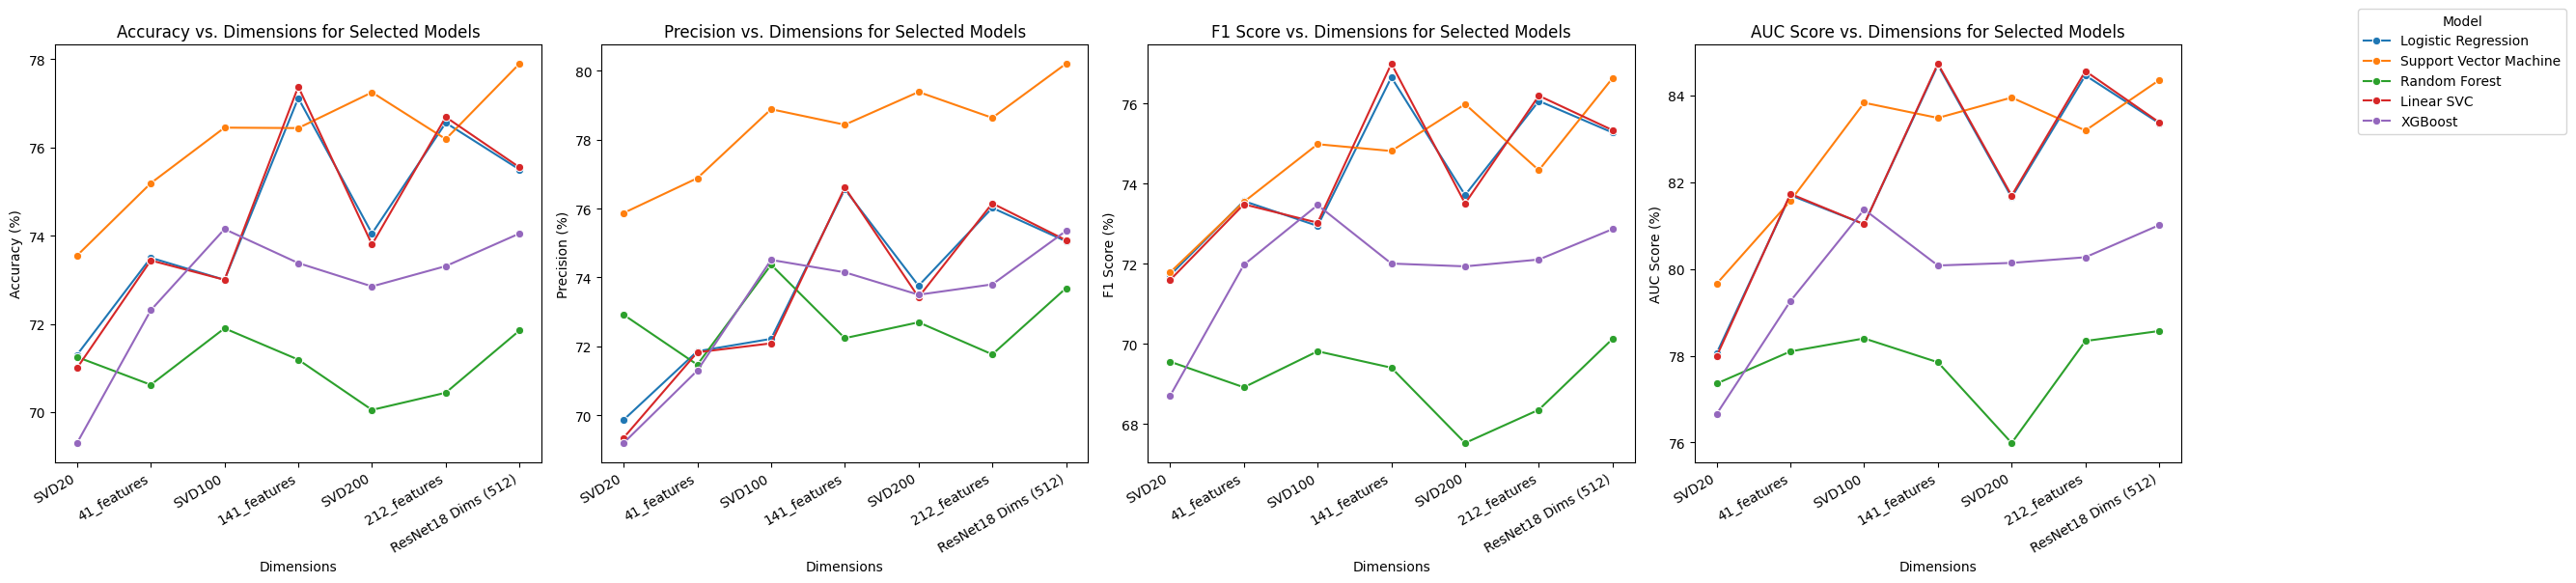

In [ ]:
plot_comparision_metrics(model_summary)

## Fine Tune SVM

## CNN



In [ ]:
! pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# Importing Classifier Modules
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score, f1_score, roc_auc_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense


#### Define CNN Model Architecture


In [ ]:
def create_cnn_model(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    return model

#### Implement CNN Training and Evaluation Function (with Progress Bar)


In [ ]:
from tqdm.keras import TqdmCallback

def train_evaluate_cnn(model, X_train, y_train, X_test, y_test, model_name):
    print(f"Training CNN model: {model_name}...")

    # Train the model with a progress bar
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0, callbacks=[TqdmCallback(verbose=1)])

    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Make predictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Calculate metrics
    prec = precision_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred) * 100
    auc_score = roc_auc_score(y_test, y_pred_proba) * 100

    print(f"Test Accuracy for {model_name}: {accuracy*100:.2f}%")

    results = {
        'Model': model_name,
        'Accuracy': accuracy * 100,
        'Precision': prec,
        'F1 Score': f1,
        'AUC Score': auc_score,
        'Loss': loss,
        'Dims': X_train.shape[1]
    }
    return results

#### Analyze Current CNN Performance


In [ ]:
print("Combined Model Summary:")
print(combined_model_summary.to_string())

Combined Model Summary:
                          Model  Accuracy  Precision  F1 Score  AUC Score   Dims    Loss
0           Logistic Regression     76.56      76.02     76.07      84.46  212.0     NaN
1        Support Vector Machine     76.19      78.63     74.34      83.19  212.0     NaN
2                    Linear SVC     76.69      76.15     76.20      84.56  212.0     NaN
3           K-Nearest Neighbors     64.62      59.63     70.37      74.57  212.0     NaN
4                 Decision Tree     59.88      59.10     58.79      59.85  212.0     NaN
5                 Random Forest     70.44      71.77     68.36      78.34  212.0     NaN
6                   Naive Bayes     63.81      59.92     68.03      72.98  212.0     NaN
7                    Perceptron     69.56      70.00     68.02      77.13  212.0     NaN
8   Stochastic Gradient Descent     73.75      71.95     73.91      81.39  212.0     NaN
9             Gradient Boosting     71.38      71.35     70.34      79.06  212.0     N

#### Enhance CNN Model Architecture


In [ ]:
from tensorflow.keras.layers import BatchNormalization, Dropout

def create_cnn_model(input_shape):
    model = Sequential()
    # First Conv1D block
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.25))

    # Second Conv1D block
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    return model

In [ ]:
# Data preparation steps moved here to ensure X_train_scaled is defined
X_scaled_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print(f"Reshaped X_scaled shape: {X_scaled_reshaped.shape}")

X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled = creat_test_train_split(X_scaled_reshaped, label)

print(f"Training set for CNN (full dim): {X_train_scaled.shape}")
print(f"Test set for CNN (full dim): {X_test_scaled.shape}")

# Original content of cell 1f7fa4a2
model_full_dim = create_cnn_model(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
model_full_dim.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model for full-dimensional embeddings (512 features) created and compiled with enhanced architecture.")
model_full_dim.summary()

Reshaped X_scaled shape: (10000, 512, 1)
Training set: (8000, 512, 1)
Test set:     (2000, 512, 1)
Training set for CNN (full dim): (8000, 512, 1)
Test set for CNN (full dim): (2000, 512, 1)
Model for full-dimensional embeddings (512 features) created and compiled with enhanced architecture.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 510, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 510, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 255, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 255, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 253, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 253, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 126, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 126, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8064)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │       403,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 410,021 (1.56 MB)

 Trainable params: 409,829 (1.56 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
X_svd200_reshaped = X_svd200.reshape(X_svd200.shape[0], X_svd200.shape[1], 1)

print(f"Reshaped X_svd200 shape: {X_svd200_reshaped.shape}")

X_train_svd200, y_train_svd200, X_test_svd200, y_test_svd200 = creat_test_train_split(X_svd200_reshaped, label)

print(f"Training set for CNN (SVD-200 dim): {X_train_svd200.shape}")
print(f"Test set for CNN (SVD-200 dim): {X_test_svd200.shape}")

model_svd200 = create_cnn_model(input_shape=(X_train_svd200.shape[1], X_train_svd200.shape[2]))
model_svd200.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model for SVD-200 dimensional embeddings created and compiled with enhanced architecture.")
model_svd200.summary()

Reshaped X_svd200 shape: (10000, 200, 1)
Training set: (8000, 200, 1)
Test set:     (2000, 200, 1)
Training set for CNN (SVD-200 dim): (8000, 200, 1)
Test set for CNN (SVD-200 dim): (2000, 200, 1)
Model for SVD-200 dimensional embeddings created and compiled with enhanced architecture.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 198, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 198, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 99, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 99, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 97, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 97, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │       153,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,421 (626.64 KB)

 Trainable params: 160,229 (625.89 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
X_svd100_reshaped = X_svd100.reshape(X_svd100.shape[0], X_svd100.shape[1], 1)

print(f"Reshaped X_svd100 shape: {X_svd100_reshaped.shape}")

X_train_svd100, y_train_svd100, X_test_svd100, y_test_svd100 = creat_test_train_split(X_svd100_reshaped, label)

print(f"Training set for CNN (SVD-100 dim): {X_train_svd100.shape}")
print(f"Test set for CNN (SVD-100 dim): {X_test_svd100.shape}")

model_svd100 = create_cnn_model(input_shape=(X_train_svd100.shape[1], X_train_svd100.shape[2]))
model_svd100.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model for SVD-100 dimensional embeddings created and compiled with enhanced architecture.")
model_svd100.summary()

Reshaped X_svd100 shape: (10000, 100, 1)
Training set: (8000, 100, 1)
Test set:     (2000, 100, 1)
Training set for CNN (SVD-100 dim): (8000, 100, 1)
Test set for CNN (SVD-100 dim): (2000, 100, 1)
Model for SVD-100 dimensional embeddings created and compiled with enhanced architecture.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 98, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 98, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 47, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 47, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1472)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │        73,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,421 (314.14 KB)

 Trainable params: 80,229 (313.39 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
X_scaled_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print(f"Reshaped X_scaled shape: {X_scaled_reshaped.shape}")

X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled = creat_test_train_split(X_scaled_reshaped, label)

print(f"Training set for CNN (full dim): {X_train_scaled.shape}")
print(f"Test set for CNN (full dim): {X_test_scaled.shape}")

Reshaped X_scaled shape: (10000, 512, 1)
Training set: (8000, 512, 1)
Test set:     (2000, 512, 1)
Training set for CNN (full dim): (8000, 512, 1)
Test set for CNN (full dim): (2000, 512, 1)


In [ ]:
model_svd20 = create_cnn_model(input_shape=(X_train_svd20.shape[1], X_train_svd20.shape[2]))
model_svd20.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model for SVD-20 dimensional embeddings created and compiled with enhanced architecture.")
model_svd20.summary()

Model for SVD-20 dimensional embeddings created and compiled with enhanced architecture.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 18, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 18, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 7, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50)             │         9,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,421 (64.14 KB)

 Trainable params: 16,229 (63.39 KB)

 Non-trainable params: 192 (768.00 B)

#### cnn (svd 20)

In [ ]:
X_svd20_reshaped = X_svd20.reshape(X_svd20.shape[0], X_svd20.shape[1], 1)

print(f"Reshaped X_svd20 shape: {X_svd20_reshaped.shape}")

X_train_svd20, y_train_svd20, X_test_svd20, y_test_svd20 = creat_test_train_split(X_svd20_reshaped, label)

print("Training CNN model for SVD-20 dimensional embeddings...")
history_svd20 = model_svd20.fit(X_train_svd20, y_train_svd20, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

loss_svd20, accuracy_svd20 = model_svd20.evaluate(X_test_svd20, y_test_svd20, verbose=0)

# Make predictions
y_pred_proba_svd20 = model_svd20.predict(X_test_svd20, verbose=0)
y_pred_svd20 = (y_pred_proba_svd20 > 0.5).astype(int)

# Calculate additional metrics
prec_svd20 = precision_score(y_test_svd20, y_pred_svd20) * 100
f1_svd20 = f1_score(y_test_svd20, y_pred_svd20) * 100
auc_score_svd20 = roc_auc_score(y_test_svd20, y_pred_proba_svd20) * 100

print(f"Test Accuracy for SVD-20 Dimensional Model: {accuracy_svd20*100:.2f}%")
print(f"Test Precision for SVD-20 Dimensional Model: {prec_svd20:.2f}%")
print(f"Test F1 Score for SVD-20 Dimensional Model: {f1_svd20:.2f}%")
print(f"Test AUC Score for SVD-20 Dimensional Model: {auc_score_svd20:.2f}%")

cnn_results.append({
    'Model': 'CNN (SVD-20)',
    'Accuracy': accuracy_svd20 * 100,
    'Precision': prec_svd20,
    'F1 Score': f1_svd20,
    'AUC Score': auc_score_svd20,
    'Loss': loss_svd20,
    'Dims': X_train_svd20.shape[1]
})

Reshaped X_svd20 shape: (10000, 20, 1)
Training set: (8000, 20, 1)
Test set:     (2000, 20, 1)
Training CNN model for SVD-20 dimensional embeddings...
Test Accuracy for SVD-20 Dimensional Model: 70.40%
Test Precision for SVD-20 Dimensional Model: 72.10%
Test F1 Score for SVD-20 Dimensional Model: 68.58%
Test AUC Score for SVD-20 Dimensional Model: 75.97%


In [ ]:
X_scaled_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print(f"Reshaped X_scaled shape: {X_scaled_reshaped.shape}")

X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled = creat_test_train_split(X_scaled_reshaped, label)

print(f"Training set for CNN (full dim): {X_train_scaled.shape}")
print(f"Test set for CNN (full dim): {X_test_scaled.shape}")

Reshaped X_scaled shape: (10000, 512, 1)
Training set: (8000, 512, 1)
Test set:     (2000, 512, 1)
Training set for CNN (full dim): (8000, 512, 1)
Test set for CNN (full dim): (2000, 512, 1)


#### cnn (full dim)

In [ ]:
cnn_results = [] # Initialize cnn_results list

model_full_dim = create_cnn_model(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
model_full_dim.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training CNN model for full-dimensional embeddings...")
cnn_full_dim_results = train_evaluate_cnn(
    model_full_dim,
    X_train_scaled, y_train_scaled,
    X_test_scaled, y_test_scaled,
    'CNN (Full-Dim)'
)
cnn_results.append(cnn_full_dim_results)

print("CNN (Full-Dim) results stored.")

Training CNN model for full-dimensional embeddings...
Training CNN model: CNN (Full-Dim)...


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Test Accuracy for CNN (Full-Dim): 74.55%
CNN (Full-Dim) results stored.


In [ ]:
cnn_full_dim_results

{'Model': 'CNN (Full-Dim)',
 'Accuracy': 74.55000281333923,
 'Precision': 74.16750756811302,
 'F1 Score': 74.27993936331481,
 'AUC Score': np.float64(81.88709174121072),
 'Loss': 0.8297956585884094,
 'Dims': 512}

In [ ]:
X_svd200_reshaped = X_svd200.reshape(X_svd200.shape[0], X_svd200.shape[1], 1)

print(f"Reshaped X_svd200 shape: {X_svd200_reshaped.shape}")

X_train_svd200, y_train_svd200, X_test_svd200, y_test_svd200 = creat_test_train_split(X_svd200_reshaped, label)

print(f"Training set for CNN (SVD-200 dim): {X_train_svd200.shape}")
print(f"Test set for CNN (SVD-200 dim): {X_test_svd200.shape}")

model_svd200 = create_cnn_model(input_shape=(X_train_svd200.shape[1], X_train_svd200.shape[2]))
model_svd200.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training CNN model for SVD-200 dimensional embeddings...")
cnn_svd200_results = train_evaluate_cnn(
    model_svd200,
    X_train_svd200, y_train_svd200,
    X_test_svd200, y_test_svd200,
    'CNN (SVD-200)'
)
cnn_results.append(cnn_svd200_results)

print(f"Test Accuracy for {cnn_svd200_results['Model']}: {cnn_svd200_results['Accuracy']:.2f}%")
print(f"Test Precision for {cnn_svd200_results['Model']}: {cnn_svd200_results['Precision']:.2f}%")
print(f"Test F1 Score for {cnn_svd200_results['Model']}: {cnn_svd200_results['F1 Score']:.2f}%")
print(f"Test AUC Score for {cnn_svd200_results['Model']}: {cnn_svd200_results['AUC Score']:.2f}%")
print(f"Test Loss for {cnn_svd200_results['Model']}: {cnn_svd200_results['Loss']:.4f}")

Reshaped X_svd200 shape: (10000, 200, 1)
Training set: (8000, 200, 1)
Test set:     (2000, 200, 1)
Training set for CNN (SVD-200 dim): (8000, 200, 1)
Test set for CNN (SVD-200 dim): (2000, 200, 1)
Training CNN model for SVD-200 dimensional embeddings...
Training CNN model: CNN (SVD-200)...


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Test Accuracy for CNN (SVD-200): 70.55%
Test Accuracy for CNN (SVD-200): 70.55%
Test Precision for CNN (SVD-200): 68.63%
Test F1 Score for CNN (SVD-200): 71.39%
Test AUC Score for CNN (SVD-200): 78.66%
Test Loss for CNN (SVD-200): 0.6835


In [ ]:
X_svd100_reshaped = X_svd100.reshape(X_svd100.shape[0], X_svd100.shape[1], 1)

print(f"Reshaped X_svd100 shape: {X_svd100_reshaped.shape}")

X_train_svd100, y_train_svd100, X_test_svd100, y_test_svd100 = creat_test_train_split(X_svd100_reshaped, label)

print(f"Training set for CNN (SVD-100 dim): {X_train_svd100.shape}")
print(f"Test set for CNN (SVD-100 dim): {X_test_svd100.shape}")

model_svd100 = create_cnn_model(input_shape=(X_train_svd100.shape[1], X_train_svd100.shape[2]))
model_svd100.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training CNN model for SVD-100 dimensional embeddings...")
cnn_svd100_results = train_evaluate_cnn(
    model_svd100,
    X_train_svd100, y_train_svd100,
    X_test_svd100, y_test_svd100,
    'CNN (SVD-100)'
)
cnn_results.append(cnn_svd100_results)

print(f"Test Accuracy for {cnn_svd100_results['Model']}: {cnn_svd100_results['Accuracy']:.2f}%")
print(f"Test Precision for {cnn_svd100_results['Model']}: {cnn_svd100_results['Precision']:.2f}%")
print(f"Test F1 Score for {cnn_svd100_results['Model']}: {cnn_svd100_results['F1 Score']:.2f}%")
print(f"Test AUC Score for {cnn_svd100_results['Model']}: {cnn_svd100_results['AUC Score']:.2f}%")
print(f"Test Loss for {cnn_svd100_results['Model']}: {cnn_svd100_results['Loss']:.4f}")

Reshaped X_svd100 shape: (10000, 100, 1)
Training set: (8000, 100, 1)
Test set:     (2000, 100, 1)
Training set for CNN (SVD-100 dim): (8000, 100, 1)
Test set for CNN (SVD-100 dim): (2000, 100, 1)
Training CNN model for SVD-100 dimensional embeddings...
Training CNN model: CNN (SVD-100)...


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Test Accuracy for CNN (SVD-100): 72.55%
Test Accuracy for CNN (SVD-100): 72.55%
Test Precision for CNN (SVD-100): 72.75%
Test F1 Score for CNN (SVD-100): 71.89%
Test AUC Score for CNN (SVD-100): 79.14%
Test Loss for CNN (SVD-100): 0.6048


## MLP

#### Define MLP Model Architecture

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

def create_mlp_model(input_shape):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(input_shape,)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    return model

print("create_mlp_model function defined successfully.")

create_mlp_model function defined successfully.


#### Prepare 2D Data Splits for MLP


In [ ]:
X_train_scaled_mlp, y_train_scaled_mlp, X_test_scaled_mlp, y_test_scaled_mlp = creat_test_train_split(X_scaled, label)
print(f"X_train_scaled_mlp shape: {X_train_scaled_mlp.shape}")
print(f"X_test_scaled_mlp shape: {X_test_scaled_mlp.shape}")


Training set: (8000, 512)
Test set:     (2000, 512)
X_train_scaled_mlp shape: (8000, 512)
X_test_scaled_mlp shape: (2000, 512)


In [ ]:
X_train_svd200_mlp, y_train_svd200_mlp, X_test_svd200_mlp, y_test_svd200_mlp = creat_test_train_split(X_svd200, label)
print(f"X_train_svd200_mlp shape: {X_train_svd200_mlp.shape}")
print(f"X_test_svd200_mlp shape: {X_test_svd200_mlp.shape}")

Training set: (8000, 200)
Test set:     (2000, 200)
X_train_svd200_mlp shape: (8000, 200)
X_test_svd200_mlp shape: (2000, 200)


In [ ]:
X_train_svd100_mlp, y_train_svd100_mlp, X_test_svd100_mlp, y_test_svd100_mlp = creat_test_train_split(X_svd100, label)
print(f"X_train_svd100_mlp shape: {X_train_svd100_mlp.shape}")
print(f"X_test_svd100_mlp shape: {X_test_svd100_mlp.shape}")

Training set: (8000, 100)
Test set:     (2000, 100)
X_train_svd100_mlp shape: (8000, 100)
X_test_svd100_mlp shape: (2000, 100)


In [ ]:
X_train_svd20_mlp, y_train_svd20_mlp, X_test_svd20_mlp, y_test_svd20_mlp = creat_test_train_split(X_svd20, label)
print(f"X_train_svd20_mlp shape: {X_train_svd20_mlp.shape}")
print(f"X_test_svd20_mlp shape: {X_test_svd20_mlp.shape}")

Training set: (8000, 20)
Test set:     (2000, 20)
X_train_svd20_mlp shape: (8000, 20)
X_test_svd20_mlp shape: (2000, 20)


#### Implement MLP Training and Evaluation Function (with Progress Bar)

In [ ]:
from tqdm.keras import TqdmCallback
from sklearn.metrics import precision_score, f1_score, roc_auc_score

def train_evaluate_mlp(model, X_train, y_train, X_test, y_test, model_name):
    print(f"Training MLP model: {model_name}...")

    # Train the model with a progress bar
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0, callbacks=[TqdmCallback(verbose=1)])

    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Make predictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Calculate metrics
    prec = round(precision_score(y_test, y_pred) * 100, 2)
    f1 = round(f1_score(y_test, y_pred) * 100, 2)
    auc_score = round(roc_auc_score(y_test, y_pred_proba) * 100, 2)

    print(f"Test Accuracy for {model_name}: {accuracy*100:.2f}%")

    results = {
        'Model': model_name,
        'Accuracy': round(accuracy * 100, 2),
        'Precision': prec,
        'F1 Score': f1,
        'AUC Score': auc_score,
        'Loss': round(loss, 4),
        'Dims': X_train.shape[1]
    }
    return results

print("train_evaluate_mlp function defined successfully.")

train_evaluate_mlp function defined successfully.


In [ ]:
from tqdm.keras import TqdmCallback
from sklearn.metrics import precision_score, f1_score, roc_auc_score

def train_evaluate_mlp(model, X_train, y_train, X_test, y_test, model_name):
    print(f"Training MLP model: {model_name}...")

    # Train the model with a progress bar
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0, callbacks=[TqdmCallback(verbose=1)])

    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Make predictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Calculate metrics
    prec = round(precision_score(y_test, y_pred) * 100, 2)
    f1 = round(f1_score(y_test, y_pred) * 100, 2)
    auc_score = round(roc_auc_score(y_test, y_pred_proba) * 100, 2)

    print(f"Test Accuracy for {model_name}: {accuracy*100:.2f}%")

    results = {
        'Model': model_name,
        'Accuracy': round(accuracy * 100, 2),
        'Precision': prec,
        'F1 Score': f1,
        'AUC Score': auc_score,
        'Loss': round(loss, 4),
        'Dims': X_train.shape[1]
    }
    return results

print("train_evaluate_mlp function defined successfully.")

train_evaluate_mlp function defined successfully.


In [ ]:
model_mlp_full_dim = create_mlp_model(input_shape=X_train_scaled_mlp.shape[1])
model_mlp_full_dim.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("MLP Model for full-dimensional embeddings (512 features) created and compiled.")
model_mlp_full_dim.summary()

MLP Model for full-dimensional embeddings (512 features) created and compiled.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,753 (292.00 KB)

 Trainable params: 74,369 (290.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
mlp_results = []

mlp_full_dim_results = train_evaluate_mlp(
    model_mlp_full_dim,
    X_train_scaled_mlp, y_train_scaled_mlp,
    X_test_scaled_mlp, y_test_scaled_mlp,
    'MLP (Full-Dim)'
)
mlp_results.append(mlp_full_dim_results)

print("MLP Full-Dim results stored.")

Training MLP model: MLP (Full-Dim)...


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Test Accuracy for MLP (Full-Dim): 76.25%
MLP Full-Dim results stored.


In [ ]:
model_mlp_svd200 = create_mlp_model(input_shape=X_train_svd200_mlp.shape[1])
model_mlp_svd200.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("MLP Model for SVD-200 dimensional embeddings created and compiled.")
model_mlp_svd200.summary()

MLP Model for SVD-200 dimensional embeddings created and compiled.


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 128)            │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,817 (136.00 KB)

 Trainable params: 34,433 (134.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
mlp_svd200_results = train_evaluate_mlp(
    model_mlp_svd200,
    X_train_svd200_mlp, y_train_svd200_mlp,
    X_test_svd200_mlp, y_test_svd200_mlp,
    'MLP (SVD-200)'
)
mlp_results.append(mlp_svd200_results)

print("MLP SVD-200 results stored.")

Training MLP model: MLP (SVD-200)...


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Test Accuracy for MLP (SVD-200): 75.40%
MLP SVD-200 results stored.


In [ ]:
model_mlp_svd100 = create_mlp_model(input_shape=X_train_svd100_mlp.shape[1])
model_mlp_svd100.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("MLP Model for SVD-100 dimensional embeddings created and compiled.")
model_mlp_svd100.summary()

MLP Model for SVD-100 dimensional embeddings created and compiled.


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,017 (86.00 KB)

 Trainable params: 21,633 (84.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
mlp_svd100_results = train_evaluate_mlp(
    model_mlp_svd100,
    X_train_svd100_mlp, y_train_svd100_mlp,
    X_test_svd100_mlp, y_test_svd100_mlp,
    'MLP (SVD-100)'
)
mlp_results.append(mlp_svd100_results)

print("MLP SVD-100 results stored.")

Training MLP model: MLP (SVD-100)...


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Test Accuracy for MLP (SVD-100): 75.35%
MLP SVD-100 results stored.


In [ ]:
model_mlp_svd20 = create_mlp_model(input_shape=X_train_svd20_mlp.shape[1])
model_mlp_svd20.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("MLP Model for SVD-20 dimensional embeddings created and compiled.")
model_mlp_svd20.summary()

MLP Model for SVD-20 dimensional embeddings created and compiled.


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
mlp_svd20_results = train_evaluate_mlp(
    model_mlp_svd20,
    X_train_svd20_mlp, y_train_svd20_mlp,
    X_test_svd20_mlp, y_test_svd20_mlp,
    'MLP (SVD-20)'
)
mlp_results.append(mlp_svd20_results)

print("MLP SVD-20 results stored.")

Training MLP model: MLP (SVD-20)...


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Test Accuracy for MLP (SVD-20): 73.60%
MLP SVD-20 results stored.


In [ ]:
mlp_df = pd.DataFrame(mlp_results)
combined_model_summary = pd.concat([model_summary, mlp_df], ignore_index=True)

print("Combined Model Summary (with MLPs):")
print(combined_model_summary.tail())

Combined Model Summary (with MLPs):
             Model  Accuracy  Precision  F1 Score  AUC Score   Dims    Loss
76         XGBoost     69.30      69.20     68.71      76.66   20.0     NaN
77  MLP (Full-Dim)     76.25      76.58     75.68      83.89  512.0  0.5157
78   MLP (SVD-200)     75.40      77.37     74.02      82.84  200.0  0.5238
79   MLP (SVD-100)     75.35      77.53     73.87      82.86  100.0  0.5006
80    MLP (SVD-20)     73.60      76.81     71.40      80.10   20.0  0.5339


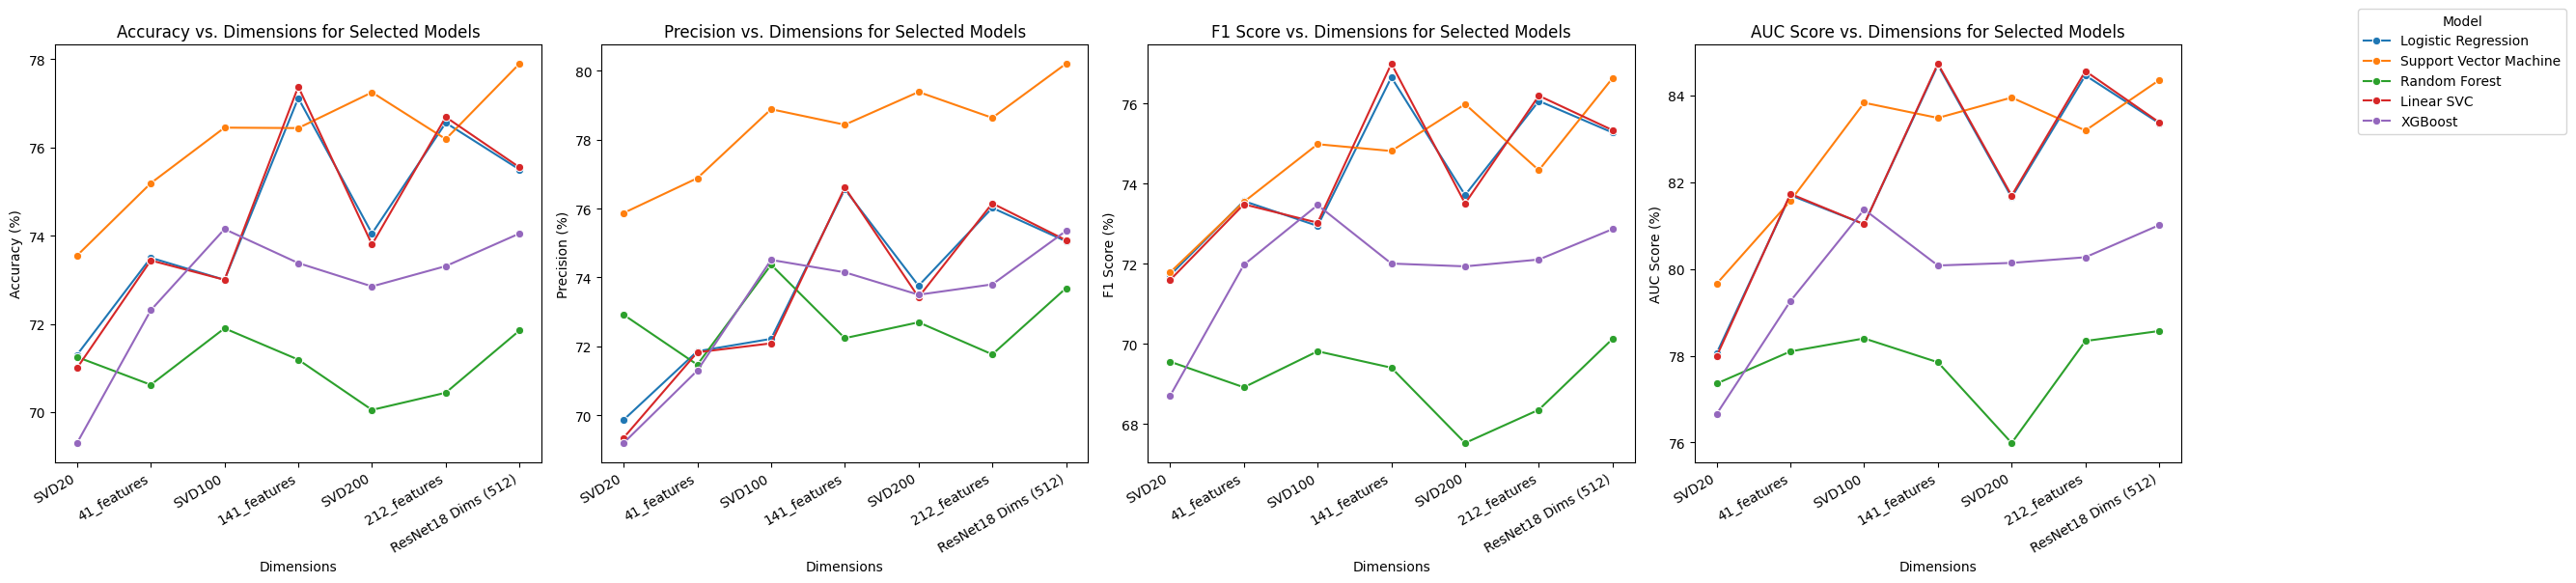

In [ ]:
plot_comparision_metrics(combined_model_summary)

## Create a Hypermodel for MLP Tuning

In [ ]:
import sys
!{sys.executable} -m pip install keras-tuner

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

def build_mlp_hypermodel(hp, input_shape):
    model = Sequential()

    # First Dense layer
    model.add(Dense(units=hp.Int('units_1', min_value=32, max_value=256, step=32),
                    activation='relu',
                    input_shape=(input_shape,)))
    model.add(BatchNormalization())
    # Tunable Dropout rate for the first layer
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)))

    # Second Dense layer
    model.add(Dense(units=hp.Int('units_2', min_value=16, max_value=128, step=16),
                    activation='relu'))
    model.add(BatchNormalization())
    # Tunable Dropout rate for the second layer
    model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model with a tunable learning rate
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

print("build_mlp_hypermodel function defined successfully.")

build_mlp_hypermodel function defined successfully.


#### Configure and Run Hyperparameter Search


In [ ]:
from keras_tuner import RandomSearch

# Instantiate the Keras Tuner
tuner = RandomSearch(
    lambda hp: build_mlp_hypermodel(hp, input_shape=X_train_scaled_mlp.shape[1]),
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='mlp_hyperparameter_tuning'
)

print("Starting hyperparameter search...")
# Run the hyperparameter search
tuner.search(X_train_scaled_mlp, y_train_scaled_mlp, epochs=10, validation_split=0.2, verbose=0)

print("Hyperparameter search complete.")

Reloading Tuner from keras_tuner_dir/mlp_hyperparameter_tuning/tuner0.json
Starting hyperparameter search...
Hyperparameter search complete.


In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print(f"  Units in first Dense layer: {best_hps.get('units_1')}")
print(f"  Dropout rate for first layer: {best_hps.get('dropout_1')}")
print(f"  Units in second Dense layer: {best_hps.get('units_2')}")
print(f"  Dropout rate for second layer: {best_hps.get('dropout_2')}")
print(f"  Learning rate: {best_hps.get('learning_rate')}")

# Build the best model found by the tuner
best_model = tuner.hypermodel.build(best_hps)

print("Best model built successfully. Ready for training and evaluation.")

Best Hyperparameters:
  Units in first Dense layer: 224
  Dropout rate for first layer: 0.4
  Units in second Dense layer: 48
  Dropout rate for second layer: 0.30000000000000004
  Learning rate: 0.01
Best model built successfully. Ready for training and evaluation.


In [ ]:
tuned_mlp_results = train_evaluate_mlp(
    best_model,
    X_train_scaled_mlp, y_train_scaled_mlp,
    X_test_scaled_mlp, y_test_scaled_mlp,
    'MLP (Tuned, Full-Dim)'
)
mlp_results.append(tuned_mlp_results)

print("Tuned MLP (Full-Dim) results stored.")

Training MLP model: MLP (Tuned, Full-Dim)...


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Test Accuracy for MLP (Tuned, Full-Dim): 76.25%
Tuned MLP (Full-Dim) results stored.


In [ ]:
mlp_df = pd.DataFrame(mlp_results)
combined_model_summary = pd.concat([model_summary, mlp_df], ignore_index=True)

print("Combined Model Summary (with MLPs):")
print(combined_model_summary.tail())

Combined Model Summary (with MLPs):
                    Model  Accuracy  Precision  F1 Score  AUC Score   Dims  \
77         MLP (Full-Dim)     76.25      76.58     75.68      83.89  512.0   
78          MLP (SVD-200)     75.40      77.37     74.02      82.84  200.0   
79          MLP (SVD-100)     75.35      77.53     73.87      82.86  100.0   
80           MLP (SVD-20)     73.60      76.81     71.40      80.10   20.0   
81  MLP (Tuned, Full-Dim)     76.25      80.28     74.11      84.01  512.0   

      Loss  
77  0.5157  
78  0.5238  
79  0.5006  
80  0.5339  
81  0.4946  


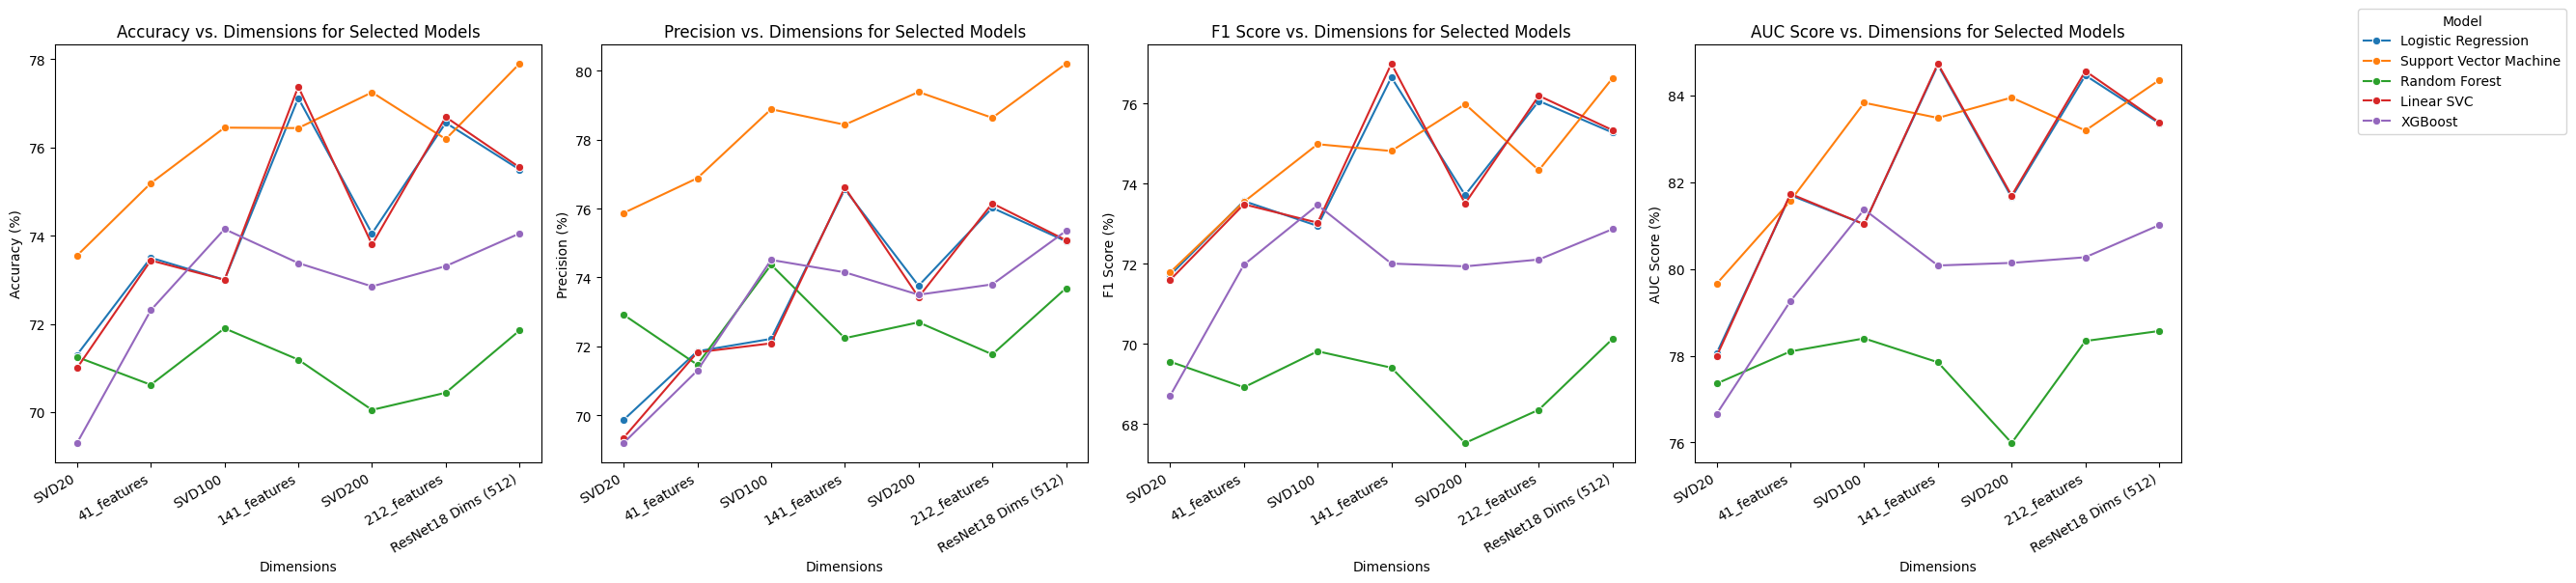

In [ ]:
plot_comparision_metrics(combined_model_summary)

## Expand Hyperparameter Search Space for MLP

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

def build_mlp_hypermodel(hp, input_shape):
    model = Sequential()

    # First Dense layer
    model.add(Dense(units=hp.Int('units_1', min_value=64, max_value=512, step=64),
                    activation=hp.Choice('activation_1', values=['relu', 'tanh', 'sigmoid']),
                    input_shape=(input_shape,)))
    model.add(BatchNormalization())
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)))

    # Second Dense layer
    model.add(Dense(units=hp.Int('units_2', min_value=32, max_value=256, step=32),
                    activation=hp.Choice('activation_2', values=['relu', 'tanh', 'sigmoid'])))
    model.add(BatchNormalization())
    model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)))

    # Optional third Dense layer
    if hp.Boolean('add_third_layer'):
        model.add(Dense(units=hp.Int('units_3', min_value=16, max_value=128, step=16),
                        activation=hp.Choice('activation_3', values=['relu', 'tanh', 'sigmoid'])))
        model.add(BatchNormalization())
        model.add(Dropout(rate=hp.Float('dropout_3', min_value=0.2, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model with an expanded set of tunable learning rates
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 5e-3, 1e-3, 5e-4, 1e-4])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

print("build_mlp_hypermodel function updated successfully with expanded search space.")

build_mlp_hypermodel function updated successfully with expanded search space.


In [ ]:
from keras_tuner import RandomSearch

# Instantiate the Keras Tuner with expanded search parameters
tuner = RandomSearch(
    lambda hp: build_mlp_hypermodel(hp, input_shape=X_train_scaled_mlp.shape[1]),
    objective='val_accuracy',
    max_trials=50, # Increased from 10 to 50
    executions_per_trial=3, # Increased from 1 to 3
    directory='keras_tuner_dir', # Ensure this is unique if running multiple times
    project_name='mlp_hyperparameter_tuning_expanded'
)

print("Starting expanded hyperparameter search...")
# Run the hyperparameter search
tuner.search(X_train_scaled_mlp, y_train_scaled_mlp, epochs=10, validation_split=0.2, verbose=0)

print("Expanded hyperparameter search complete.")

Starting expanded hyperparameter search...
Expanded hyperparameter search complete.


In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print(f"  Units in first Dense layer: {best_hps.get('units_1')}")
print(f"  Activation for first Dense layer: {best_hps.get('activation_1')}")
print(f"  Dropout rate for first layer: {best_hps.get('dropout_1')}")
print(f"  Units in second Dense layer: {best_hps.get('units_2')}")
print(f"  Activation for second Dense layer: {best_hps.get('activation_2')}")
print(f"  Dropout rate for second layer: {best_hps.get('dropout_2')}")

if best_hps.get('add_third_layer'):
    print(f"  Added third layer: {best_hps.get('add_third_layer')}")
    print(f"  Units in third Dense layer: {best_hps.get('units_3')}")
    print(f"  Activation for third Dense layer: {best_hps.get('activation_3')}")
    print(f"  Dropout rate for third layer: {best_hps.get('dropout_3')}")
else:
    print(f"  Added third layer: {best_hps.get('add_third_layer')}")

print(f"  Learning rate: {best_hps.get('learning_rate')}")

# Build the best model found by the tuner
best_model_expanded = tuner.hypermodel.build(best_hps)

print("Best model built successfully. Ready for training and evaluation.")

Best Hyperparameters:
  Units in first Dense layer: 448
  Activation for first Dense layer: relu
  Dropout rate for first layer: 0.4
  Units in second Dense layer: 64
  Activation for second Dense layer: relu
  Dropout rate for second layer: 0.4
  Added third layer: True
  Units in third Dense layer: 80
  Activation for third Dense layer: sigmoid
  Dropout rate for third layer: 0.4
  Learning rate: 0.0005
Best model built successfully. Ready for training and evaluation.


In [ ]:
tuned_mlp_expanded_results = train_evaluate_mlp(
    best_model_expanded,
    X_train_scaled_mlp, y_train_scaled_mlp,
    X_test_scaled_mlp, y_test_scaled_mlp,
    'MLP (Tuned, Expanded Search)'
)
mlp_results.append(tuned_mlp_expanded_results)

print("Tuned MLP (Expanded Search) results stored.")

Training MLP model: MLP (Tuned, Expanded Search)...


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Test Accuracy for MLP (Tuned, Expanded Search): 76.35%
Tuned MLP (Expanded Search) results stored.


In [ ]:
mlp_df = pd.DataFrame(mlp_results)
combined_model_summary = pd.concat([model_summary, mlp_df], ignore_index=True)

print("Combined Model Summary (with MLPs):")
print(combined_model_summary.tail())

Combined Model Summary (with MLPs):
                           Model  Accuracy  Precision  F1 Score  AUC Score  \
78                 MLP (SVD-200)     75.40      77.37     74.02      82.84   
79                 MLP (SVD-100)     75.35      77.53     73.87      82.86   
80                  MLP (SVD-20)     73.60      76.81     71.40      80.10   
81         MLP (Tuned, Full-Dim)     76.25      80.28     74.11      84.01   
82  MLP (Tuned, Expanded Search)     76.35      77.84     75.27      83.82   

     Dims    Loss  
78  200.0  0.5238  
79  100.0  0.5006  
80   20.0  0.5339  
81  512.0  0.4946  
82  512.0  0.5103  


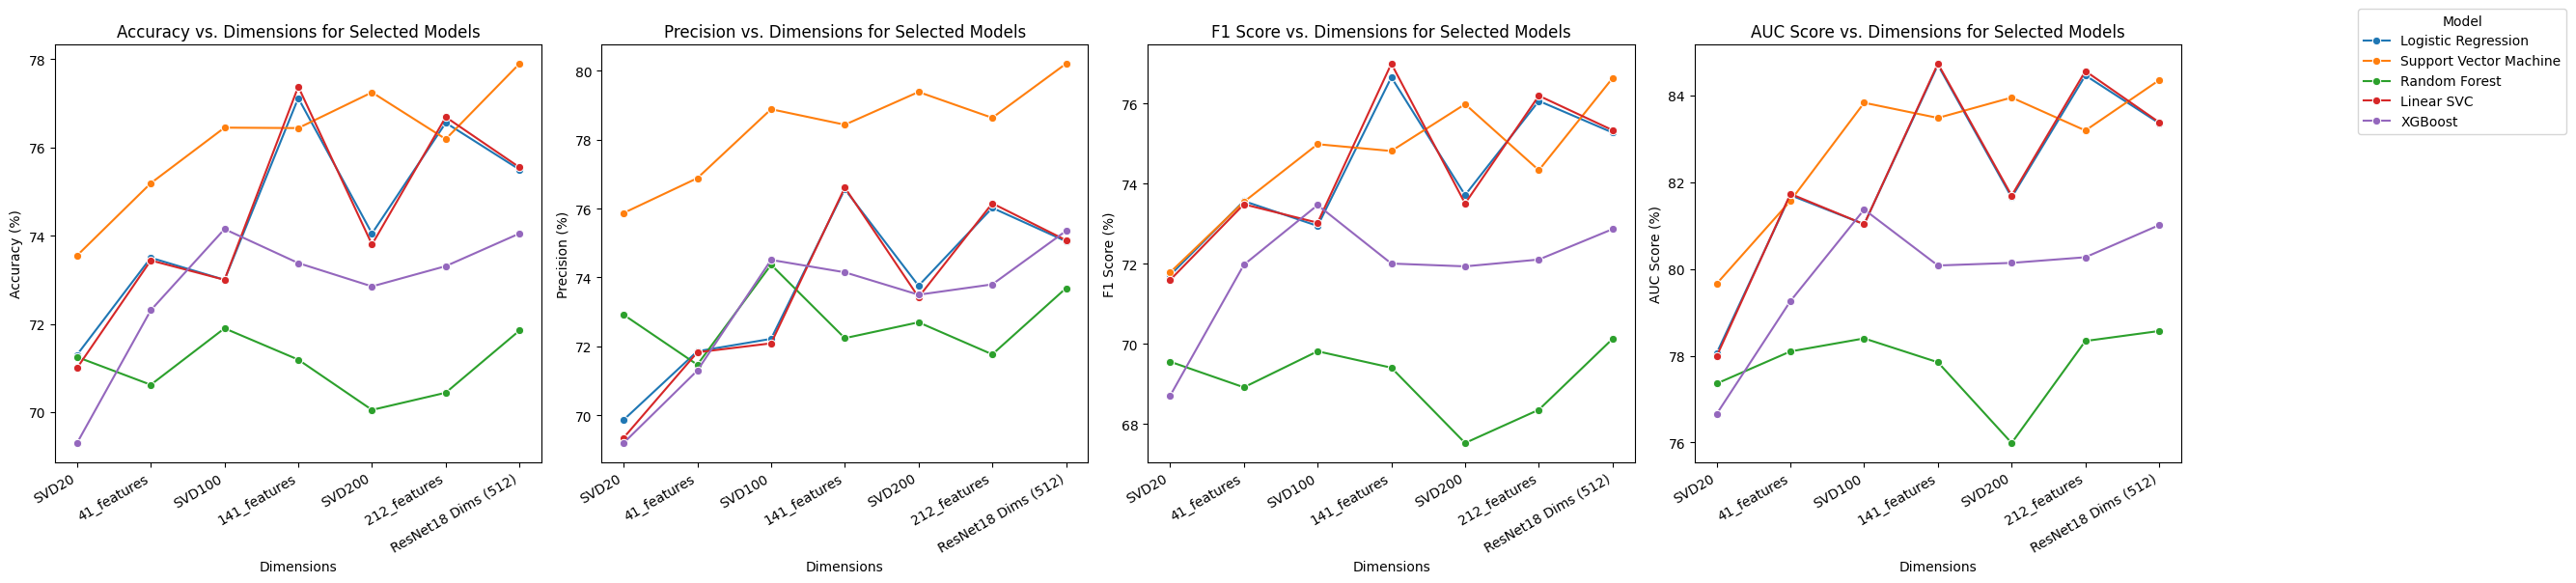

In [ ]:
plot_comparision_metrics(combined_model_summary)

## Fine tune svm (using grid search C, gamma)

In [ ]:
from sklearn.model_selection import GridSearchCV

train_X_512, train_y_512, test_X_512, test_y_512 = creat_test_train_split(X_scaled, label)

param_grid_svc = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

print("GridSearchCV imported, data splits created, and param_grid_svc defined.")

Training set: (8000, 512)
Test set:     (2000, 512)
GridSearchCV imported, data splits created, and param_grid_svc defined.


In [ ]:
from sklearn.svm import SVC

def fine_tune_svc(train_X, train_y, test_X, test_y, param_grid):
    print("Starting SVC hyperparameter tuning...")
    svc = SVC(random_state=42, probability=True) # probability=True for AUC score with predict_proba

    grid_search = GridSearchCV(
        estimator=svc,
        param_grid=param_grid,
        cv=5,
        n_jobs=1,
        verbose=2,
        scoring='accuracy'
    )

    grid_search.fit(train_X, train_y)

    print("\nBest hyperparameters found:", grid_search.best_params_)
    print("Best cross-validation accuracy:", round(grid_search.best_score_ * 100, 2), "%")

    best_svc_model = grid_search.best_estimator_
    y_pred = best_svc_model.predict(test_X)

    acc = round(best_svc_model.score(test_X, test_y) * 100, 2)
    prec = round(precision_score(test_y, y_pred) * 100, 2)
    f1 = round(f1_score(test_y, y_pred) * 100, 2)

    # Calculate AUC Score
    auc_score = np.nan
    if hasattr(best_svc_model, 'predict_proba'):
        y_proba = best_svc_model.predict_proba(test_X)[:, 1]
        if len(np.unique(test_y)) > 1:
            auc_score = round(roc_auc_score(test_y, y_proba) * 100, 2)
    elif hasattr(best_svc_model, 'decision_function'):
        y_score = best_svc_model.decision_function(test_X)
        if len(np.unique(test_y)) > 1:
            auc_score = round(roc_auc_score(test_y, y_score) * 100, 2)

    print(f"\nFine-tuned SVC Model Metrics (Test Set):")
    print(f"  Accuracy: {acc}%")
    print(f"  Precision: {prec}%")
    print(f"  F1 Score: {f1}%")
    print(f"  AUC Score: {auc_score}%")

    return {
        'Model': 'SVC (Tuned, Full-Dim)',
        'Accuracy': acc,
        'Precision': prec,
        'F1 Score': f1,
        'AUC Score': auc_score,
        'Dims': train_X.shape[1],
        'Loss': np.nan # Loss not directly applicable for SVC in this context
    }

fine_tuned_svc_results = fine_tune_svc(train_X_512, train_y_512, test_X_512, test_y_512, param_grid_svc)


Starting SVC hyperparameter tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 3.1min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 3.0min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 2.9min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 2.8min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 2.7min
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time= 2.5min
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time= 2.5min
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time= 2.7min
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time= 2.6min
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time= 2.6min
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time= 2.7min
[CV] END 

In [ ]:
fine_tuned_svc_results

{'Model': 'SVC (Tuned, Full-Dim)',
 'Accuracy': 77.3,
 'Precision': 79.21,
 'F1 Score': 76.13,
 'AUC Score': np.float64(84.12),
 'Dims': 512,
 'Loss': nan}

In [ ]:
fine_tuned_svc_df = pd.DataFrame([fine_tuned_svc_results])
fine_tuned_svc_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,F1 Score,AUC Score,Dims,Loss
0,"SVC (Tuned, Full-Dim)",77.3,79.21,76.13,84.12,512,NaN


## Fine tuning SVM (weight weak performing class)

In [ ]:
import sys
!{sys.executable} -m pip install keras-tuner

In [ ]:
# Re-mount drive and define path, helper functions, and data for SVC training
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

drive.mount('/content/drive', force_remount=True)
path = "/content/drive/MyDrive/ML1 Final Project"

def lalos_scaling_function(df):
  id_col = df.columns[0]
  label_col = "label" if "label" in df.columns else df.columns[1]
  last_col = df.columns[-1]

  cols_to_drop = [c for c in [id_col, last_col] if c != label_col]

  raw_y = df[label_col].copy()
  X = df.drop(columns=cols_to_drop + [label_col]).copy()

  X = X.apply(pd.to_numeric, errors="coerce")
  if X.isna().any().any():
      X = X.fillna(X.median(numeric_only=True))

  if raw_y.dtype == object:
      y = raw_y.astype(str).str.lower().map({"fake": 0, "real": 1})
      if y.isna().any():
          y = pd.Series(pd.factorize(raw_y.astype(str))[0], index=raw_y.index)
  else:
      y = pd.Series(pd.to_numeric(raw_y, errors="coerce"), index=raw_y.index)

  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)

  return X, X_scaled, y

def creat_test_train_split(df_embeds, label):
  assert label is not None, "Label cannot be null for prediction."
  X = df_embeds
  y = label

  train_X, test_X, train_y, test_y = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  return train_X, train_y, test_X, test_y

df_embeds = pd.read_csv(path + "/cleaned_data_resnet18_face_embeddings.csv")
_, X_scaled, label = lalos_scaling_function(df_embeds)

print("Data loaded and prepared for SVC training.")

Mounted at /content/drive
Data loaded and prepared for SVC training.


In [ ]:
import sys
!{sys.executable} -m pip install keras-tuner

--- Training SVC model (kernel=rbf, random_state=42) ---
Training SVC...
SVC training complete.

--- SVC Model Performance (kernel=rbf, random_state=42) ---
Accuracy:  77.55%
Precision: 80.11%
F1 Score:  76.16%
AUC Score: 84.42%

--- Confusion Matrix ---
[[834 178]
 [271 717]]


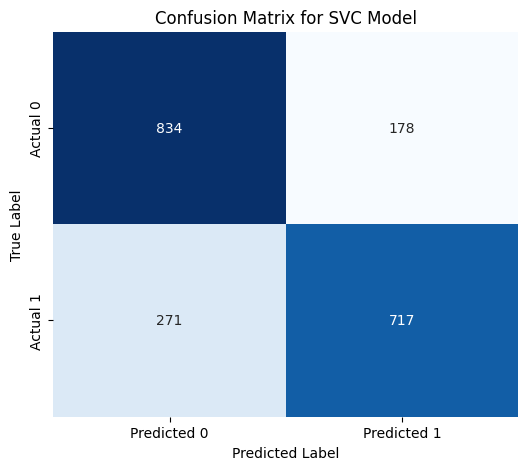

In [ ]:
print('--- Training SVC model (kernel=rbf, random_state=42) ---')

# Split data for SVC training
train_X, train_y, test_X, test_y = creat_test_train_split(X_scaled, label)

# Initialize and train the SVC model
svc_model = SVC(kernel='rbf', random_state=42, probability=True) # probability=True needed for AUC
print("Training SVC...")
svc_model.fit(train_X, train_y)
print("SVC training complete.")

# Make predictions
y_pred = svc_model.predict(test_X)
y_pred_proba = svc_model.predict_proba(test_X)[:, 1]

# Calculate metrics
accuracy = round(svc_model.score(test_X, test_y) * 100, 2)
precision = round(precision_score(test_y, y_pred) * 100, 2)
f1 = round(f1_score(test_y, y_pred) * 100, 2)
auc_score = round(roc_auc_score(test_y, y_pred_proba) * 100, 2)

print(f"\n--- SVC Model Performance (kernel=rbf, random_state=42) ---")
print(f"Accuracy:  {accuracy}%")
print(f"Precision: {precision}%")
print(f"F1 Score:  {f1}%")
print(f"AUC Score: {auc_score}%")

# Confusion Matrix
cm = confusion_matrix(test_y, y_pred)
print("\n--- Confusion Matrix ---")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for SVC Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()